# Exploration 01 — exploratory data analysis of every QM9 field (X2: the full training pool)

> **Exploratory** (docs/EVALUATION_RULES.md, "Exploration"). This notebook chooses no model setting itself; its findings become
> the cleaning, feature-engineering and scaling decisions in notebooks 02 and 03.
> **Data:** the training pool P only (99,198 molecules). No test molecule, no development molecule and no
> held-out formula is read.

**Part 1 of the classical analysis, rebuilt for exploration X2** (DECISIONS.md, 2026-10-06). X1 ran this analysis
on a 7,131-molecule pool capped at 25 molecules per formula. X2 puts accuracy first (Track A), so the EDA now covers
the data the models will actually train on, and adds two questions X1 left open: **what an atom's charge depends
on** (the unit a dipole model should predict) and **how the high-|μ| zwitterions can be recognized from geometry**.

| Notebook | Step | Uses from earlier steps |
|---|---|---|
| **01 (this)** | exploratory data analysis of every field, molecule and atom level | — |
| 02 | data cleaning and feature engineering (molecule- and atom-level) | the integrity, redundancy, charge and zwitterion findings |
| 03 | scaling, target transform and dimension (Track A and Track B) | the distribution shapes and tails |
| 04 | models: accurate (Track A) then quantum-comparable (Track B) | the features and the chosen scaling |
| 05 | generalization to new formulas, error analysis | everything above |

QM9 provides, per molecule, atomic numbers Z and 3D coordinates R (the brief's inputs), the target |μ|, and much
more from the same DFT calculation: Mulliken charges, 14 other properties, vibrational frequencies, and SMILES and
InChI strings. **This EDA examines all of them**, to learn which carry information about |μ|, which are redundant
or broken, and which a headline model may use at all.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from qm9dipole import REPO_ROOT
from qm9dipole.data import load_qm9_table
from qm9dipole.eda import FROM_ZR, DFT, SCALAR_PROPERTIES, data_dictionary, integrity_checks, per_molecule_summaries
from qm9dipole.explore import load_config
from qm9dipole.plots import (AXIS, DIVERGING, INK_SECONDARY, MUTED, ROLE_COLORS, ROLE_LABELS, SEQUENTIAL,
                             SERIES, SURFACE, use_style)
from qm9dipole.provenance import save_result
from qm9dipole.splits import load_splits

use_style()
FIG_DIR = REPO_ROOT / "figures"
CFG = load_config()
SUBSAMPLE = CFG["eda"]["subsample"]  # for the slow estimators (mutual information, per-atom fits)

table = load_qm9_table()
splits = load_splits()
P = table.set_index("id").loc[splits.pool].reset_index()
# Guard: nothing held out (test, development, held-out formulas) enters this notebook.
held_out = set().union(*(set(ids) for name, ids in splits.sets().items() if name != "pool"))
assert not set(P["id"]) & held_out
assert not set(P["formula"]) & (set(splits.unseen_formulas) | set(splits.dev_unseen_formulas))
y = P.set_index("id")["mu"]
formula = P.set_index("id")["formula"]
mol = P.set_index("id")
rng = np.random.default_rng(2026)
sub = np.sort(rng.choice(len(P), size=min(SUBSAMPLE, len(P)), replace=False))
print(f"parsed table: {table.shape[0]:,} molecules × {table.shape[1]} columns")
print(f"training pool P: {len(P):,} molecules, {formula.nunique()} formulas, {P['n_atoms'].sum():,} atoms "
      f"(no held-out molecule or formula); subsample for slow estimators: {len(sub):,}")

parsed table: 133,885 molecules × 27 columns
training pool P: 99,198 molecules, 497 formulas, 1,776,116 atoms (no held-out molecule or formula); subsample for slow estimators: 20,000


## 1. Shape, columns and roles

Every column of the parsed table, with its unit and **role**. The role matters as much as the content:
- **headline input / function of Z and R:** usable by headline models. The brief's pipeline is composition +
  geometry → model → |μ|;
- **DFT output:** computed in the same B3LYP calculation that produced |μ|. A model fed these answers "given the
  electron density, what is |μ|?", a different question from the brief's, so they are exploration-only (docs/EVALUATION_RULES.md
  rule 1). This holds for Track A too: a model that needs a DFT output cannot predict anything a DFT run has not
  already given;
- **identifier:** names and bookkeeping, not inputs.

In [3]:
dd = data_dictionary()
dd["dtype"] = dd["column"].map(lambda c: type(P[c].iloc[0]).__name__ if P[c].dtype == object else str(P[c].dtype))
display(dd.style.hide(axis="index"))
print(dd["role"].value_counts().to_string())

column,per,unit,meaning,role,dtype
id,molecule,,QM9 index (GDB-17 numbering),identifier / bookkeeping,int64
formula,molecule,,"element counts, e.g. C2H6O (from Z)",function of Z and R (headline-legal),str
n_atoms,molecule,,number of atoms (from Z),function of Z and R (headline-legal),int64
n_heavy,molecule,,"number of C, N, O, F atoms (from Z)",function of Z and R (headline-legal),int64
Z,atom,,atomic number,headline input,ndarray
R,atom,Å,Cartesian coordinates of the B3LYP-optimized geometry,headline input,ndarray
q,atom,e,Mulliken partial charge,DFT output (exploration only),ndarray
A,molecule,GHz,rotational constant (largest),function of Z and R (headline-legal),float64
B,molecule,GHz,rotational constant,function of Z and R (headline-legal),float64
C,molecule,GHz,rotational constant (smallest),function of Z and R (headline-legal),float64


role
DFT output (exploration only)           13
function of Z and R (headline-legal)     6
identifier / bookkeeping                 5
headline input                           2
target                                   1


## 2. Data types, missing values and integrity

Missing values, internal consistency and physical sanity, checked on every pool molecule. The integrity rules come
from the QM9 readme and from physics: a neutral molecule's charges sum to zero; a stable geometry has no imaginary
vibrational frequency; enthalpy exceeds internal energy by RT; rotational constants follow from the masses and
coordinates.

In [4]:
checks = integrity_checks(P)
display(checks.style.format({"max deviation": "{:.2g}"}, na_rep="").hide(axis="index"))

summaries = per_molecule_summaries(P)
doubled = summaries["n_freqs_listed"] == 2 * summaries["n_freqs_expected"]
print(f"frequency lists printed twice in the raw file: {doubled.sum()} of {len(P):,} pool molecules")

check,checked,violations,max deviation,note
len(Z) = len(R) = len(q) = n_atoms,99198,0,,
no missing scalar values,99198,0,,
neutral: |Σ q| < 1e-4 e,99198,0,6e-06,
μ ≥ 0,99198,0,,
gap = lumo − homo (values are rounded to 1e-4 Ha),99198,0,0.0001,
H − U = RT at 298.15 K (0.000944 Ha),99198,0,1e-06,
U0 < U and G < H,99198,0,,
"A ≥ B ≥ C, or A = 0 (linear)",99198,0,,
"rotational constants = 505.379 GHz·amu·Å² / I(Z, R)",99198,0,1.4e-05,relative; I from isotope masses and R
frequencies: 3n − 6 listed (3n − 5 if linear),99198,255,,exactly twice that is a doubled list in the raw file


frequency lists printed twice in the raw file: 255 of 99,198 pool molecules


## 3. Duplicates: removed before splitting

X1 found molecules listed twice in QM9 (same formula, same geometry, same |μ|). Notebook 01 now drops the extra copies
before any split is drawn (DECISIONS.md), so none may remain in P. Recomputed here from geometry, independently.
Standard InChI is no identity test: it merges **tautomers** (molecules differing only in where a hydrogen sits),
which are different molecules with different dipoles.

In [5]:
from qm9dipole.cleaning import duplicate_groups
from qm9dipole.descriptors import cm_spectrum

spectra = np.stack([cm_spectrum(z, r) for z, r in zip(P["Z"], P["R"])])
geo = duplicate_groups(P["id"].to_numpy(), P["formula"], spectra, CFG["cleaning"]["duplicate_cm_decimals"])
assert geo.empty, "a geometric duplicate survived the split build"
by_inchi = P[P["inchi"].duplicated(keep=False)].groupby("inchi")["id"].apply(list)
inchi_range = by_inchi.map(lambda ids: float(np.ptp(y.loc[ids])))
print(f"geometric duplicates left in P: {len(geo)}")
print(f"same InChI but different geometry (tautomers): {by_inchi.map(len).sum():,} molecules in {len(by_inchi):,} groups; "
      f"|μ| differs within a group by up to {inchi_range.max():.1f} D (median {inchi_range.median():.2f} D)")

geometric duplicates left in P: 0
same InChI but different geometry (tautomers): 3,892 molecules in 1,824 groups; |μ| differs within a group by up to 8.5 D (median 1.98 D)


## 4. Summary statistics of every scalar field

The 15 properties of each record's second line, the molecule-level counts, and scalar summaries of the
array-valued fields. Skewness above ~1 or a large kurtosis flags a long tail.

In [6]:
scalars = mol[list(SCALAR_PROPERTIES) + ["n_atoms", "n_heavy"]].join(
    summaries[["n_C", "n_H", "n_N", "n_O", "n_F", "centroid_offset", "q_max_abs", "freq_min", "freq_max"]])
stats = scalars.describe(percentiles=[0.01, 0.5, 0.99]).T
stats["skew"], stats["kurtosis"], stats["distinct"] = scalars.skew(), scalars.kurt(), scalars.nunique()
role = dict(zip(dd["column"], dd["role"]))
stats.insert(0, "role", [role.get(c, FROM_ZR if c.startswith("n_") or c == "centroid_offset" else DFT)
                         for c in stats.index])
display(stats.drop(columns="count").style.format(precision=3, thousands=","))

,role,mean,std,min,1%,50%,99%,max,skew,kurtosis,distinct
A,function of Z and R (headline-legal),12.046,"2,102.153",0.000,1.875,3.092,8.296,"619,867.683",272.123,"77,723.077","84,827"
B,function of Z and R (headline-legal),1.413,1.817,0.341,0.545,1.376,2.740,437.904,188.568,"40,906.854","72,692"
C,function of Z and R (headline-legal),1.133,1.254,0.335,0.515,1.088,2.117,282.945,169.989,"33,485.297","64,558"
mu,target,2.706,1.487,0.000,0.136,2.522,6.543,29.556,1.489,9.480,"44,708"
alpha,DFT output (exploration only),75.162,7.977,6.310,52.630,75.760,93.240,196.620,-0.452,2.294,"5,218"
homo,DFT output (exploration only),-0.240,0.022,-0.396,-0.295,-0.241,-0.178,-0.102,0.172,1.682,"1,754"
lumo,DFT output (exploration only),0.010,0.046,-0.175,-0.099,0.011,0.091,0.117,-0.172,-0.541,"2,376"
gap,DFT output (exploration only),0.251,0.046,0.025,0.152,0.249,0.343,0.505,0.015,-0.583,"2,569"
r2,DFT output (exploration only),"1,184.099",278.851,19.000,650.699,"1,139.860","2,132.826","3,374.753",1.315,3.852,"98,588"
zpve,DFT output (exploration only),0.148,0.032,0.016,0.073,0.148,0.228,0.274,-0.010,0.230,"59,844"


## 5. The target: |μ|

|μ| measures how far the molecule's centres of positive and negative charge are pulled apart (1 D ≈ 0.21 e·Å). The
panels compare the raw scale with two variance-stabilizing transforms; notebook 03 tests by CV whether either helps.

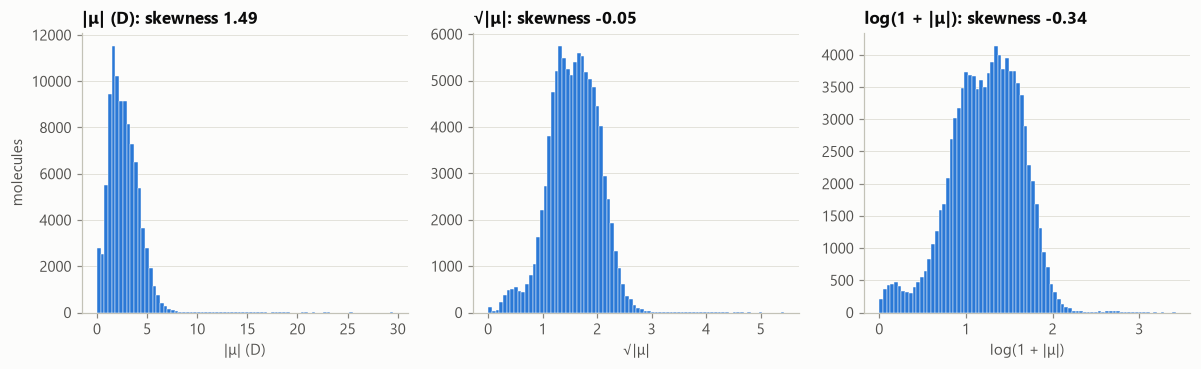

99,198 molecules: mean 2.71 D, median 2.52 D, std 1.49 D
exactly 0 D: 41; below 0.25 D: 2008 (2.0%); ≥ 6 D: 1824 (1.84%); ≥ 9 D: 223 (0.22%); largest 29.6 D


,MAE (D),RMSE (D)
always predict the mean,1.154,1.487
always predict the median,1.146,1.498


In [7]:
from qm9dipole.provenance import figure_file, results_file
transforms = {"|μ| (D)": y, "√|μ|": np.sqrt(y), "log(1 + |μ|)": np.log1p(y)}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (name, v) in zip(axes, transforms.items()):
    ax.hist(v, bins=80, color=SERIES[0], edgecolor=SURFACE, linewidth=0.3)
    ax.set(xlabel=name, title=f"{name}: skewness {v.skew():.2f}")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("molecules")
fig.savefig(figure_file("explore01_target.png"))
plt.show()

print(f"{len(y):,} molecules: mean {y.mean():.2f} D, median {y.median():.2f} D, std {y.std():.2f} D")
print(f"exactly 0 D: {(y == 0).sum()}; below 0.25 D: {(y < 0.25).sum()} ({(y < 0.25).mean():.1%}); "
      f"≥ 6 D: {(y >= 6).sum()} ({(y >= 6).mean():.2%}); ≥ 9 D: {(y >= 9).sum()} ({(y >= 9).mean():.2%}); "
      f"largest {y.max():.1f} D")
constant = pd.DataFrame({"MAE (D)": [(y - y.mean()).abs().mean(), (y - y.median()).abs().mean()],
                         "RMSE (D)": [np.sqrt(((y - y.mean()) ** 2).mean()), np.sqrt(((y - y.median()) ** 2).mean())]},
                        index=["always predict the mean", "always predict the median"])
display(constant.style.format("{:.3f}"))

## 6. Every scalar field, one at a time

Each panel shows the 0.5–99.5 percentile range so the bulk is visible; the title gives the skewness, and the corner
note gives the full range when the tails reach beyond the plot. Blue: functions of Z and R. Orange: DFT outputs
(exploration only).

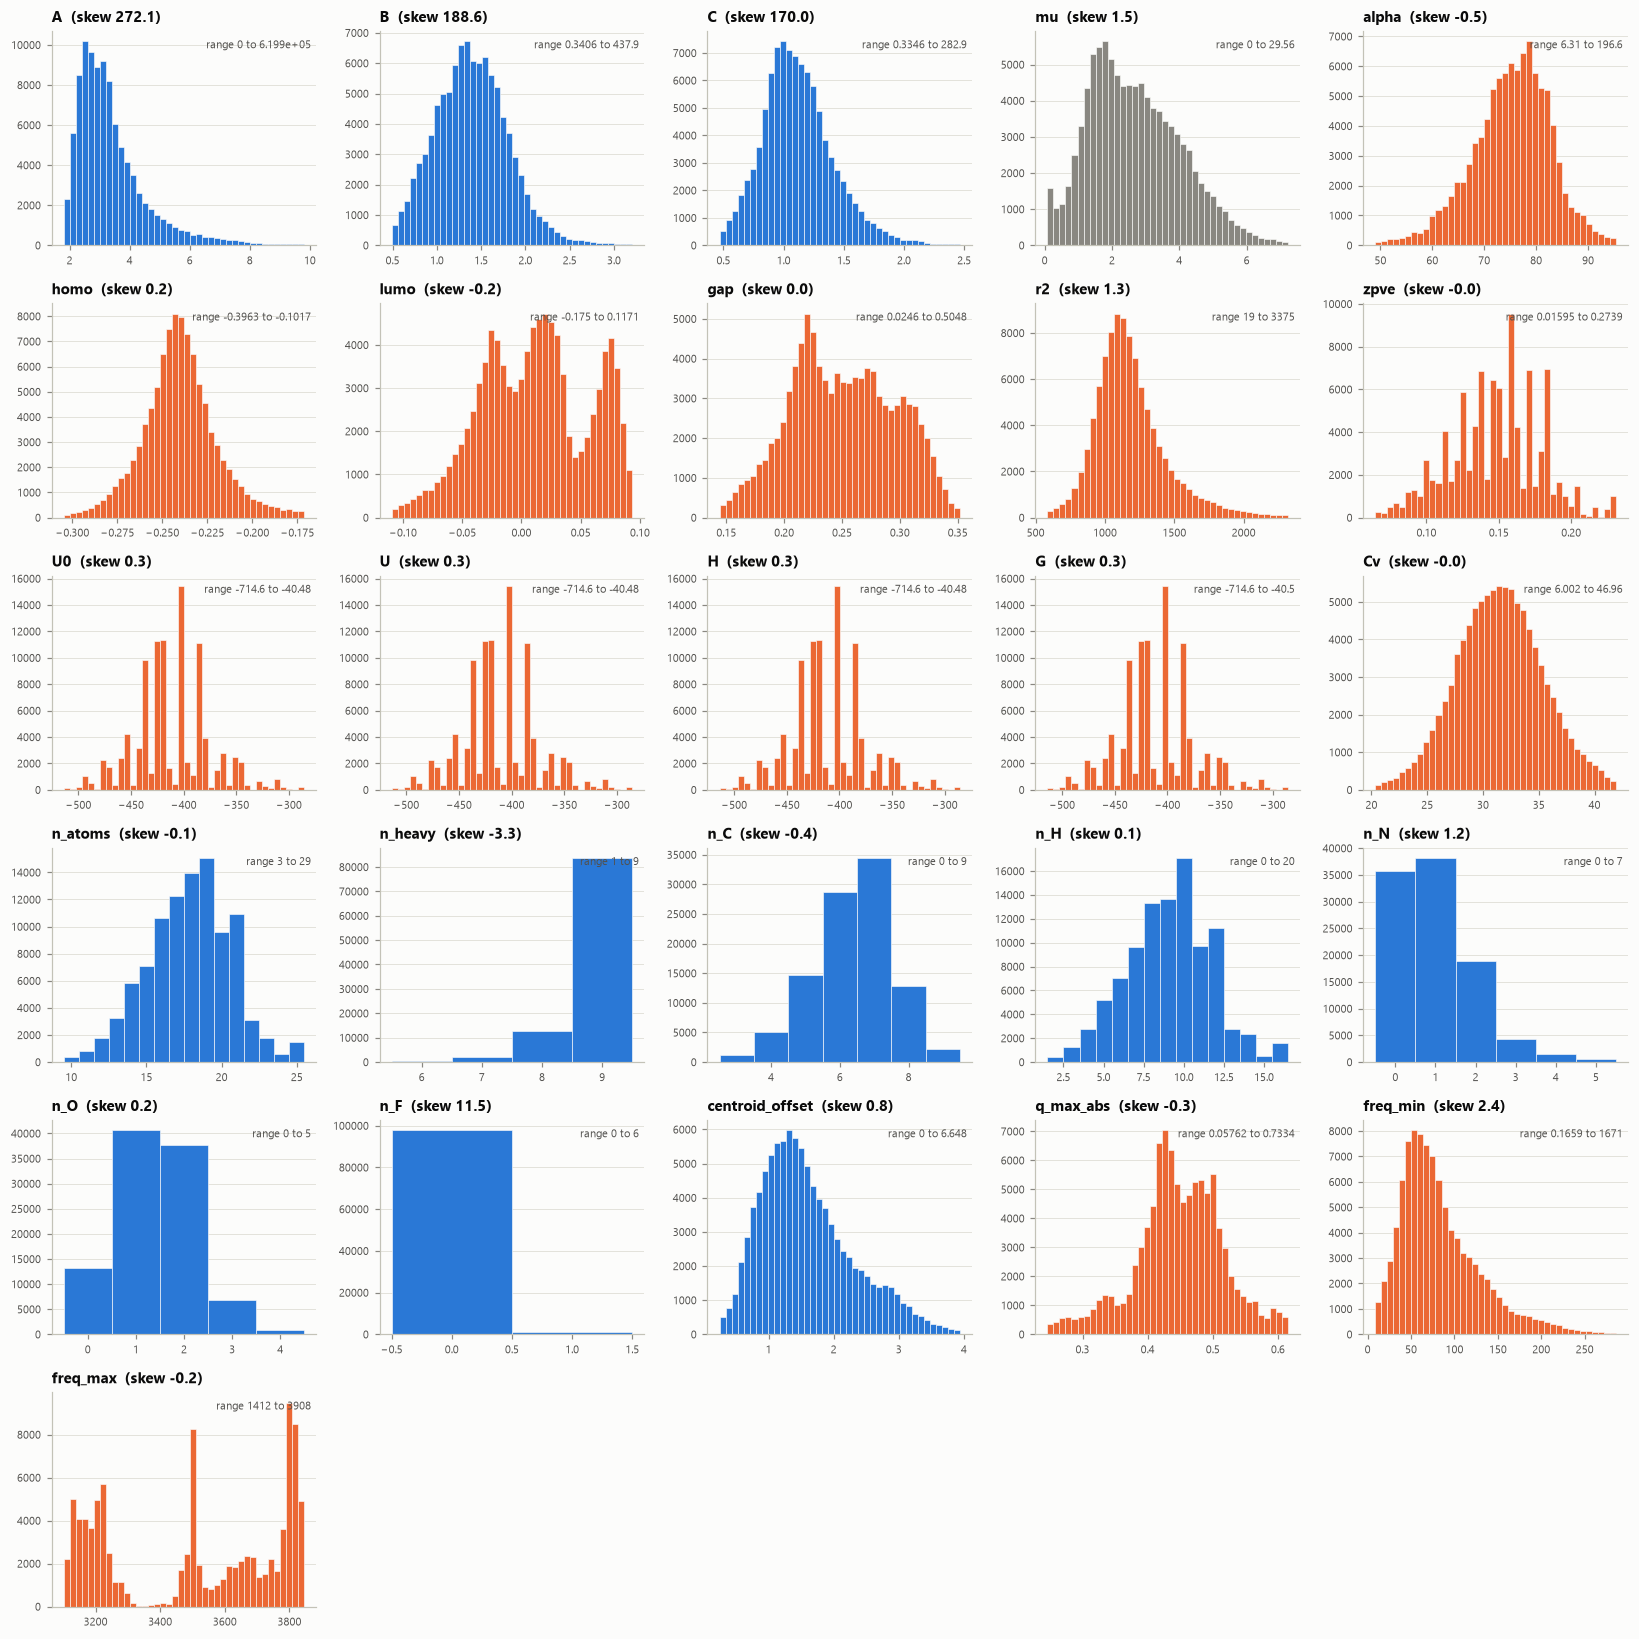

In [8]:
cols = list(stats.index)
n_cols = 5
fig, axes = plt.subplots(int(np.ceil(len(cols) / n_cols)), n_cols, figsize=(15, 2.5 * np.ceil(len(cols) / n_cols)))
for ax, c in zip(axes.flat, cols):
    v = scalars[c]
    lo, hi = v.quantile([0.005, 0.995])
    inside = v[(v >= lo) & (v <= hi)]
    color = ROLE_COLORS["dft"] if stats.loc[c, "role"] == DFT else (MUTED if c == "mu" else ROLE_COLORS["legal"])
    bins = np.arange(lo - 0.5, hi + 1.5) if v.nunique() <= 30 and (v == v.round()).all() else 40
    ax.hist(inside, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.4)
    ax.set_title(f"{c}  (skew {v.skew():.1f})", fontsize=9.5)
    ax.tick_params(labelsize=7.5)
    ax.grid(axis="x", visible=False)
    if v.max() > hi or v.min() < lo:
        ax.text(0.98, 0.92, f"range {v.min():.4g} to {v.max():.4g}", transform=ax.transAxes, ha="right",
                fontsize=7, color=INK_SECONDARY)
for ax in list(axes.flat)[len(cols):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(figure_file("explore01_scalar_distributions.png"))
plt.show()

## 7. Formula imbalance at full scale

The 25-per-formula cap of X1 hid how lopsided QM9 is. Without it, a few formulas dominate, and almost every
molecule has nine heavy atoms. A model trained on P learns mostly from those, which is what the development holdout
of whole formulas (notebook 05) checks.

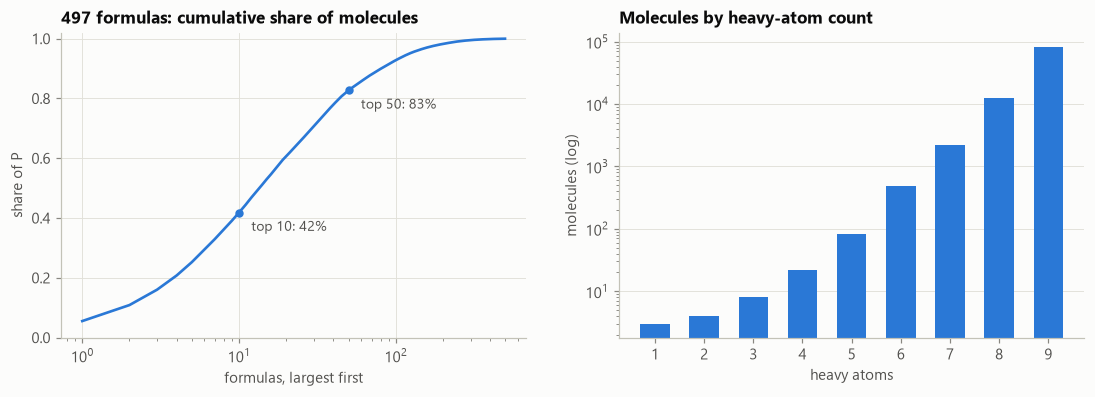

median 12 molecules per formula; 173 formulas have fewer than 5; the largest, C7H10O2, has 5,504; nine heavy atoms: 84% of P


In [9]:
per_formula = formula.value_counts()
share = per_formula.cumsum() / per_formula.sum()
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.6))
ax0.plot(np.arange(1, len(share) + 1), share.to_numpy(), color=SERIES[0])
for k in (10, 50):
    ax0.annotate(f"top {k}: {share.iloc[k - 1]:.0%}", (k, share.iloc[k - 1]), xytext=(8, -12),
                 textcoords="offset points", color=INK_SECONDARY, fontsize=9)
    ax0.scatter([k], [share.iloc[k - 1]], color=SERIES[0], s=20, zorder=3)
ax0.set(xscale="log", xlabel="formulas, largest first", ylabel="share of P", ylim=(0, 1.02),
        title=f"{len(per_formula)} formulas: cumulative share of molecules")
heavy = mol["n_heavy"].value_counts().sort_index()
ax1.bar(heavy.index, heavy.to_numpy(), color=SERIES[0], width=0.6)
ax1.set(yscale="log", xlabel="heavy atoms", ylabel="molecules (log)", xticks=heavy.index,
        title="Molecules by heavy-atom count")
ax1.grid(axis="x", visible=False)
fig.savefig(figure_file("explore01_formula_imbalance.png"))
plt.show()
print(f"median {per_formula.median():.0f} molecules per formula; {(per_formula < 5).sum()} formulas have fewer than 5; "
      f"the largest, {per_formula.index[0]}, has {per_formula.iloc[0]:,}; nine heavy atoms: {heavy.get(9, 0) / len(P):.0%} of P")

## 8. The per-atom fields: Z, R, q and the frequencies

### 8a. Coordinates R: what do raw coordinates encode?
If QM9 stored every molecule centred and aligned in a standard frame, raw coordinates could carry chemistry
directly. If not, a model must use invariant descriptors.

In [10]:
from qm9dipole.features import ISOTOPE_MASS

def frame_alignment(z, r):
    "Largest off-diagonal of the inertia tensor in the stored frame, relative to its trace (0 if aligned)."
    m = np.array([ISOTOPE_MASS[int(a)] for a in z])
    X = r - (m[:, None] * r).sum(0) / m.sum()
    second = np.einsum("i,ij,ik->jk", m, X, X)
    tensor = np.trace(second) * np.eye(3) - second
    return np.abs(tensor - np.diag(np.diag(tensor))).max() / np.trace(tensor)

alignment = np.array([frame_alignment(z, r) for z, r in zip(P["Z"], P["R"])])
print(f"centroid distance from the origin: median {summaries['centroid_offset'].median():.2f} Å, "
      f"max {summaries['centroid_offset'].max():.2f} Å")
print(f"stored frame aligned with the principal axes (off-diagonal < 1% of trace): {(alignment < 0.01).mean():.1%}")

centroid distance from the origin: median 1.46 Å, max 6.65 Å
stored frame aligned with the principal axes (off-diagonal < 1% of trace): 1.6%


### 8b. Bond lengths: bonds and bond orders hidden in R

Bonds are inferred from distances (d < 1.15 × sum of covalent radii; DECISIONS.md). Within one element pair, bond
length tracks bond order. Empty valleys between the peaks let bond orders be counted from geometry alone. The
cutoffs chosen in X1 (`features.BOND_ORDER_RULES`, dashed) are re-checked here on 14× more molecules.

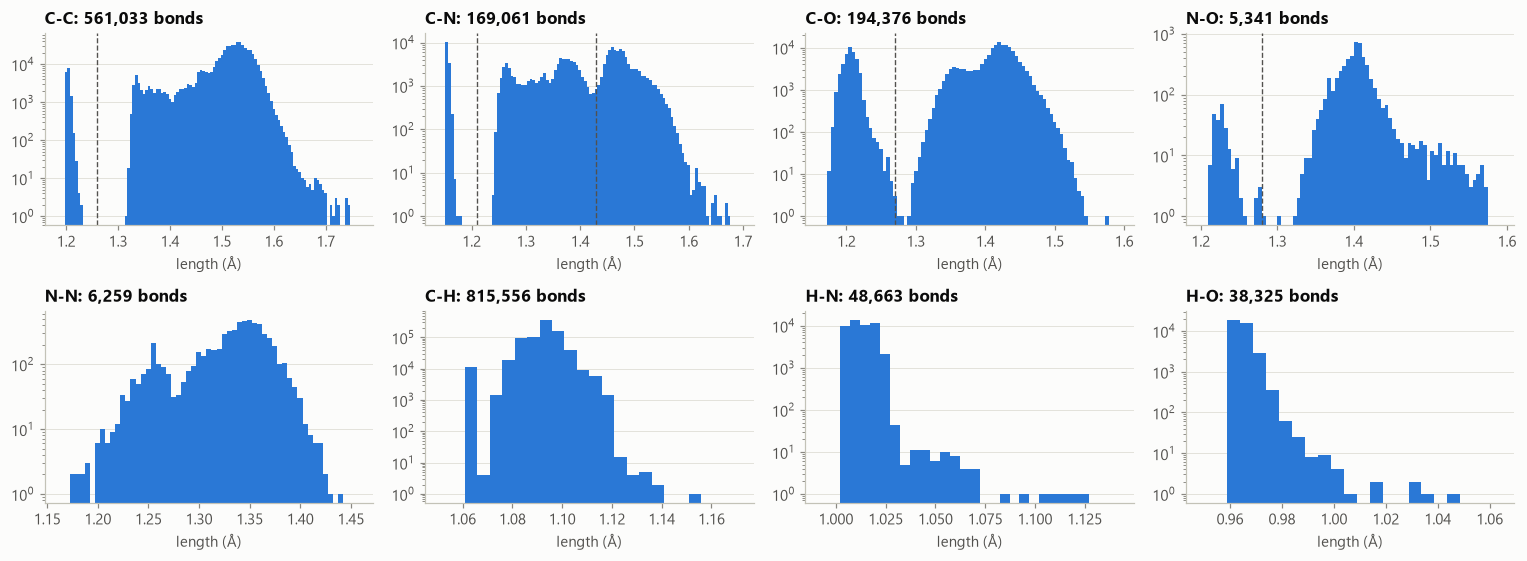

triple_C-C    cutoff 1.26 Å: 0 of 561,033 C-C bonds within ±0.02 Å of it
triple_C-N    cutoff 1.21 Å: 0 of 169,061 C-N bonds within ±0.02 Å of it
multiple_C-N  cutoff 1.43 Å: 12,518 of 169,061 C-N bonds within ±0.02 Å of it
double_C-O    cutoff 1.27 Å: 69 of 194,376 C-O bonds within ±0.02 Å of it
double_N-O    cutoff 1.28 Å: 6 of 5,341 N-O bonds within ±0.02 Å of it


In [11]:
from qm9dipole.eda import bond_lengths
from qm9dipole.features import BOND_ORDER_RULES

lengths = bond_lengths(P)
sym = {1: "H", 6: "C", 7: "N", 8: "O", 9: "F"}
cut = {}
for name, (za, zb), lo, hi in BOND_ORDER_RULES:
    cut.setdefault(f"{sym[za]}-{sym[zb]}", []).append(hi)
pairs = ["C-C", "C-N", "C-O", "N-O", "N-N", "C-H", "H-N", "H-O"]
fig, axes = plt.subplots(2, 4, figsize=(14, 5.2))
for ax, pair in zip(axes.flat, pairs):
    v = lengths.loc[lengths["pair"] == pair, "length"]
    ax.hist(v, bins=np.arange(v.min() - 0.01, v.max() + 0.02, 0.005), color=ROLE_COLORS["legal"], linewidth=0)
    for c in cut.get(pair, []):
        ax.axvline(c, color=INK_SECONDARY, linewidth=0.9, linestyle="--")
    ax.set(title=f"{pair}: {len(v):,} bonds", xlabel="length (Å)", yscale="log")
    ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(figure_file("explore01_bond_lengths.png"))
plt.show()
for name, (za, zb), lo, hi in BOND_ORDER_RULES:
    pair = f"{sym[za]}-{sym[zb]}"
    v = lengths.loc[lengths["pair"] == pair, "length"]
    near = ((v > hi - 0.02) & (v < hi + 0.02)).sum()
    print(f"{name:13s} cutoff {hi:.2f} Å: {near:,} of {len(v):,} {pair} bonds within ±0.02 Å of it")

### 8c. Mulliken charges q (DFT output, exploration only)

Per-atom partial charges from the DFT electron density. If μ were exactly a sum of point charges, |Σ qᵢ rᵢ| would
equal it. It doesn't, because charges are an approximation and the electron cloud is not point-like, but how close
it gets bounds what a model that "knew the charges" could do. This is the motivation for X2's charge model: it
predicts a charge per atom and adds them up as vectors.

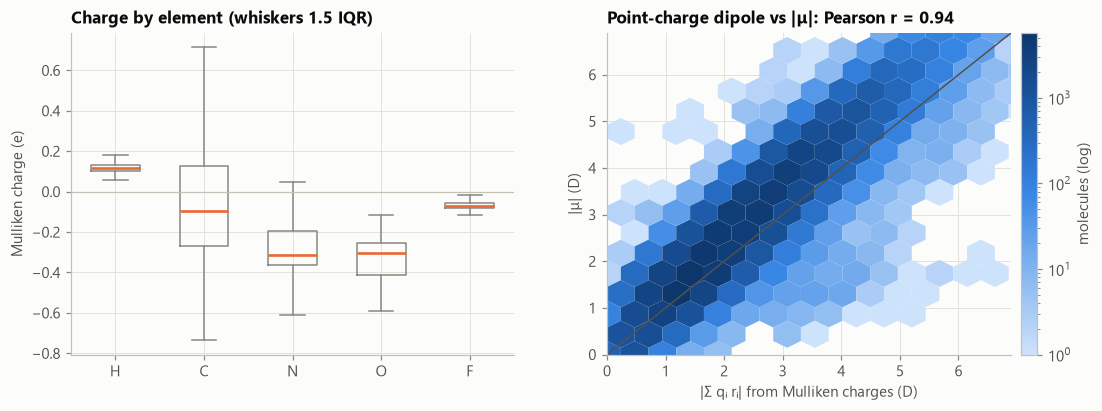

In [12]:
from qm9dipole.features import charge_features

element = {1: "H", 6: "C", 7: "N", 8: "O", 9: "F"}
charge = pd.DataFrame([charge_features(q, r) for q, r in zip(P["q"], P["R"])], index=mol.index,
                      columns=["charge_dipole_D", "max_abs_charge", "charge_separation"])
per_atom_q = np.concatenate(P["q"].to_numpy())
per_atom_el = np.array([element[int(a)] for z in P["Z"] for a in z])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.1]})
order = ["H", "C", "N", "O", "F"]
style = dict(color=MUTED, linewidth=1)
ax0.boxplot([per_atom_q[per_atom_el == e] for e in order], tick_labels=order, showfliers=False, widths=0.55,
            medianprops=dict(color=ROLE_COLORS["dft"], linewidth=1.75), boxprops=style, whiskerprops=style, capprops=style)
ax0.axhline(0, color=AXIS, linewidth=0.8)
ax0.set(ylabel="Mulliken charge (e)", title="Charge by element (whiskers 1.5 IQR)")
hb = ax1.hexbin(charge["charge_dipole_D"], y, gridsize=60, bins="log", cmap=SEQUENTIAL, mincnt=1, linewidths=0)
r = np.corrcoef(charge["charge_dipole_D"], y)[0, 1]
lim = float(np.percentile(np.r_[charge["charge_dipole_D"], y], 99.5))
ax1.plot([0, lim], [0, lim], color=INK_SECONDARY, linewidth=1)
ax1.set(xlim=(0, lim), ylim=(0, lim), xlabel="|Σ qᵢ rᵢ| from Mulliken charges (D)", ylabel="|μ| (D)",
        title=f"Point-charge dipole vs |μ|: Pearson r = {r:.2f}")
fig.colorbar(hb, ax=ax1, label="molecules (log)", pad=0.02)
fig.savefig(figure_file("explore01_charges.png"))
plt.show()

### 8d. What does an atom's charge depend on?

If a charge is mostly a function of the atom's local environment, a model can learn charges from geometry. To check,
per-atom environment features computed from Z and R alone (`atoms.describe`: element, bonded neighbours, bond orders,
two- and three-bond shells, rings, radial and directional environment, charge-equilibration charge) are regressed
onto the Mulliken charge, atom by atom. This uses a DFT output as the *target* of a description, never as a model
input, so it is exploration only, and it is out-of-sample (5-fold CV over molecules of the subsample).

Two references: the element alone, and the charge from **charge equilibration** (QEq; Rappé & Goddard 1991), a
classical physics model that balances tabulated electronegativities against Coulomb interactions using only Z and R.

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from qm9dipole.atoms import ATOM_FEATURE_NAMES, build_atom_data

atoms_P, blocks_P = build_atom_data(P[["id", "Z", "R"]])  # every pool molecule, in parallel (about a minute)
atoms_sub = atoms_P.subset(P["id"].to_numpy()[sub])
q_sub = np.concatenate(P.iloc[sub]["q"].to_numpy())
groups_atom = np.repeat(np.arange(atoms_sub.n_molecules), atoms_sub.n_atoms)
Xa = atoms_sub.X.astype(np.float64)
cols = {name: k for k, name in enumerate(ATOM_FEATURE_NAMES)}
onehot = Xa[:, [cols[f"is_{e}"] for e in ("C", "H", "N", "O", "F")]]
cv = GroupKFold(5)
fits = {
    "element only (5 indicators)": (RidgeCV(alphas=np.logspace(-3, 3, 13)), onehot),
    "QEq charge alone": (RidgeCV(alphas=[1e-6]), Xa[:, [cols["qeq_charge"]]]),
    "all per-atom features, linear": (RidgeCV(alphas=np.logspace(-3, 3, 13)), Xa),
    "all per-atom features, boosted trees": (HistGradientBoostingRegressor(max_iter=300, random_state=0), Xa),
}
rows = []
oof_q = {}
for name, (model, X) in fits.items():
    pred = np.empty_like(q_sub)
    for tr, va in cv.split(X, q_sub, groups_atom):
        pred[va] = model.fit(X[tr], q_sub[tr]).predict(X[va])
    oof_q[name] = pred
    rows.append({"predictor of the Mulliken charge": name, "R² (out of fold)": 1 - np.mean((q_sub - pred) ** 2) / q_sub.var(),
                 "MAE (e)": np.abs(q_sub - pred).mean()})
charge_fit = pd.DataFrame(rows).set_index("predictor of the Mulliken charge")
display(charge_fit.style.format({"R² (out of fold)": "{:.3f}", "MAE (e)": "{:.4f}"})
        .set_caption(f"{len(q_sub):,} atoms of {atoms_sub.n_molecules:,} molecules; folds group atoms by molecule"))
print(f"QEq vs Mulliken charge: Pearson r = {np.corrcoef(Xa[:, cols['qeq_charge']], q_sub)[0, 1]:.3f}")

,R² (out of fold),MAE (e)
predictor of the Mulliken charge,,
element only (5 indicators),0.459,0.1064
QEq charge alone,0.780,0.0795
"all per-atom features, linear",0.966,0.0272
"all per-atom features, boosted trees",0.994,0.0115


QEq vs Mulliken charge: Pearson r = 0.883


In [14]:
# If the boosted-tree charges were exact, how good a dipole would they give? Rebuild |Σ q̂ᵢ cᵢ| per molecule.
best = "all per-atom features, boosted trees"
pos = atoms_sub.pos.astype(np.float64)
def point_dipole(q):
    v = np.add.reduceat((q - np.repeat(np.add.reduceat(q, atoms_sub.offsets[:-1]) / atoms_sub.n_atoms,
                                       atoms_sub.n_atoms))[:, None] * pos, atoms_sub.offsets[:-1], axis=0)
    return 4.80320 * np.linalg.norm(v, axis=1)
y_sub = y.loc[atoms_sub.ids].to_numpy()
for name, q in [("Mulliken charges (DFT)", q_sub), ("charges predicted from Z, R (" + best + ")", oof_q[best]),
                ("QEq charges (Z, R, no fitting)", Xa[:, cols["qeq_charge"]])]:
    d = point_dipole(q)
    print(f"{name:70s} |Σ qᵢ cᵢ| vs |μ|: Pearson r = {np.corrcoef(d, y_sub)[0, 1]:.3f}")

Mulliken charges (DFT)                                                 |Σ qᵢ cᵢ| vs |μ|: Pearson r = 0.937
charges predicted from Z, R (all per-atom features, boosted trees)     |Σ qᵢ cᵢ| vs |μ|: Pearson r = 0.902
QEq charges (Z, R, no fitting)                                         |Σ qᵢ cᵢ| vs |μ|: Pearson r = 0.725


### 8e. Vibrational frequencies (DFT output, exploration only)

Each molecule has 3n − 6 harmonic modes. Doubled lists are counted once here.

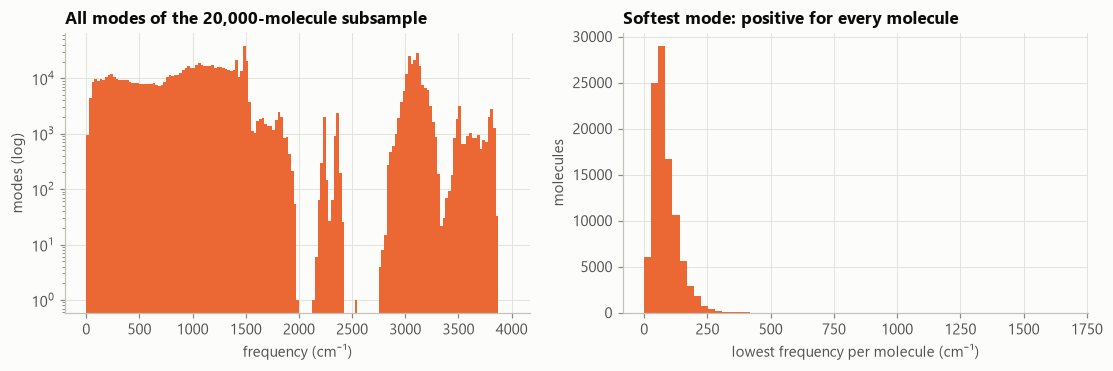

In [15]:
from qm9dipole.cleaning import clean_frequencies

clean = [clean_frequencies(f, n) for f, n in zip(P["freqs"], P["n_atoms"])]
lowest = np.array([f.min() for f in clean])
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.3))
all_modes = np.concatenate([clean[i] for i in sub])
ax0.hist(all_modes, bins=np.arange(0, 4000, 25), color=ROLE_COLORS["dft"], linewidth=0)
ax0.set(yscale="log", xlabel="frequency (cm⁻¹)", ylabel="modes (log)", title=f"All modes of the {len(sub):,}-molecule subsample")
ax1.hist(lowest, bins=60, color=ROLE_COLORS["dft"], linewidth=0)
ax1.set(xlabel="lowest frequency per molecule (cm⁻¹)", ylabel="molecules", title="Softest mode: positive for every molecule")
fig.savefig(figure_file("explore01_frequencies.png"))
plt.show()

## 9. Which fields carry information about |μ|?

Three measures for every scalar field: **Pearson r** (linear), **Spearman ρ** (monotone, robust to tails) and
**mutual information** (MI, nats; any dependence; k-nearest-neighbour estimator on the subsample). Two
geometry-derived physics estimates are added for reference: the QEq dipole (Z and R only) and the Mulliken
point-charge dipole (DFT, exploration only).

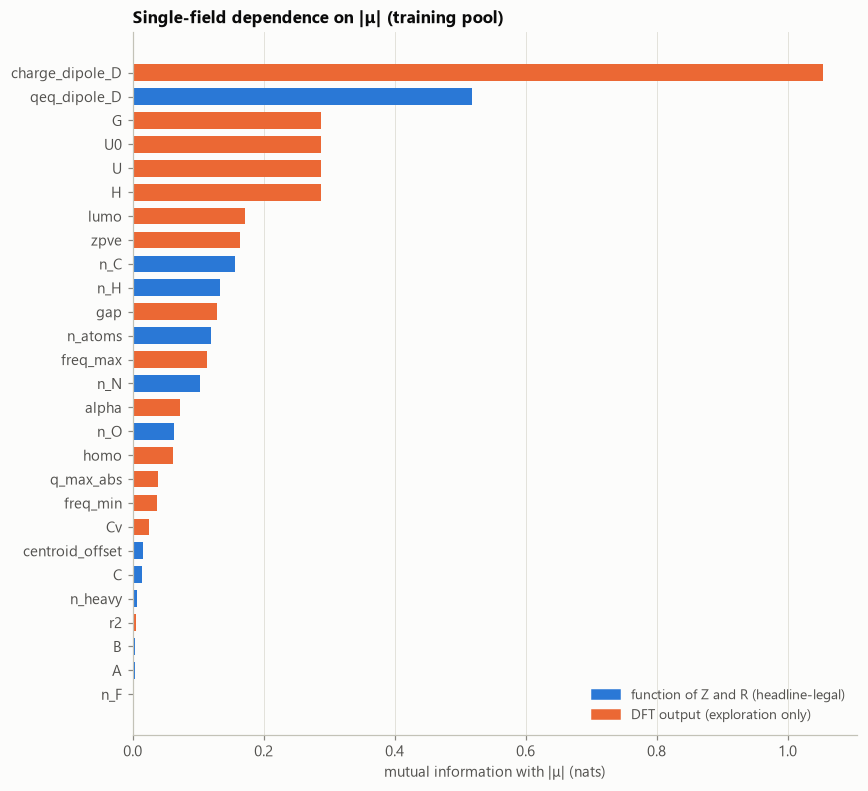

,role,Pearson r,Spearman ρ,MI (nats)
charge_dipole_D,dft,+0.94,+0.92,1.054
qeq_dipole_D,legal,+0.72,+0.76,0.518
G,dft,-0.24,-0.23,0.288
U0,dft,-0.24,-0.23,0.288
U,dft,-0.24,-0.23,0.288
H,dft,-0.24,-0.23,0.288
lumo,dft,-0.38,-0.41,0.171
zpve,dft,-0.35,-0.36,0.163
n_C,legal,-0.36,-0.37,0.157
n_H,legal,-0.36,-0.37,0.134


In [16]:
from matplotlib.patches import Patch
from sklearn.feature_selection import mutual_info_regression
qeq_dipole = blocks_P["qeq_dipole_D"].reindex(mol.index)
candidates = scalars.drop(columns="mu").join(charge[["charge_dipole_D"]]).join(qeq_dipole)
candidates = candidates.loc[:, candidates.nunique() > 1]
mi = mutual_info_regression(candidates.iloc[sub].to_numpy(), y.iloc[sub].to_numpy(), random_state=0)
legal_extra = {"qeq_dipole_D"}
assoc = pd.DataFrame({
    "role": ["legal" if (c in legal_extra or stats["role"].get(c, DFT) != DFT) else "dft" for c in candidates.columns],
    "Pearson r": candidates.corrwith(y), "Spearman ρ": candidates.corrwith(y, method="spearman"), "MI (nats)": mi,
}, index=candidates.columns).sort_values("MI (nats)", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 0.27 * len(assoc) + 1))
show = assoc.iloc[::-1]
ax.barh(show.index, show["MI (nats)"], color=[ROLE_COLORS[r] for r in show["role"]], height=0.7)
ax.legend(handles=[Patch(color=ROLE_COLORS[k], label=ROLE_LABELS[k]) for k in ("legal", "dft")], loc="lower right")
ax.set(xlabel="mutual information with |μ| (nats)", title="Single-field dependence on |μ| (training pool)")
ax.grid(axis="y", visible=False)
fig.savefig(figure_file("explore01_mutual_information.png"))
plt.show()
display(assoc.style.format({"Pearson r": "{:+.2f}", "Spearman ρ": "{:+.2f}", "MI (nats)": "{:.3f}"}))

## 10. Redundancy: how the fields relate to each other

Spearman correlations among all scalar fields, ordered by hierarchical clustering. Blocks of near-±1 are redundant:
they carry the same information up to a monotone transform, which notebook 02's cleaning rule removes.

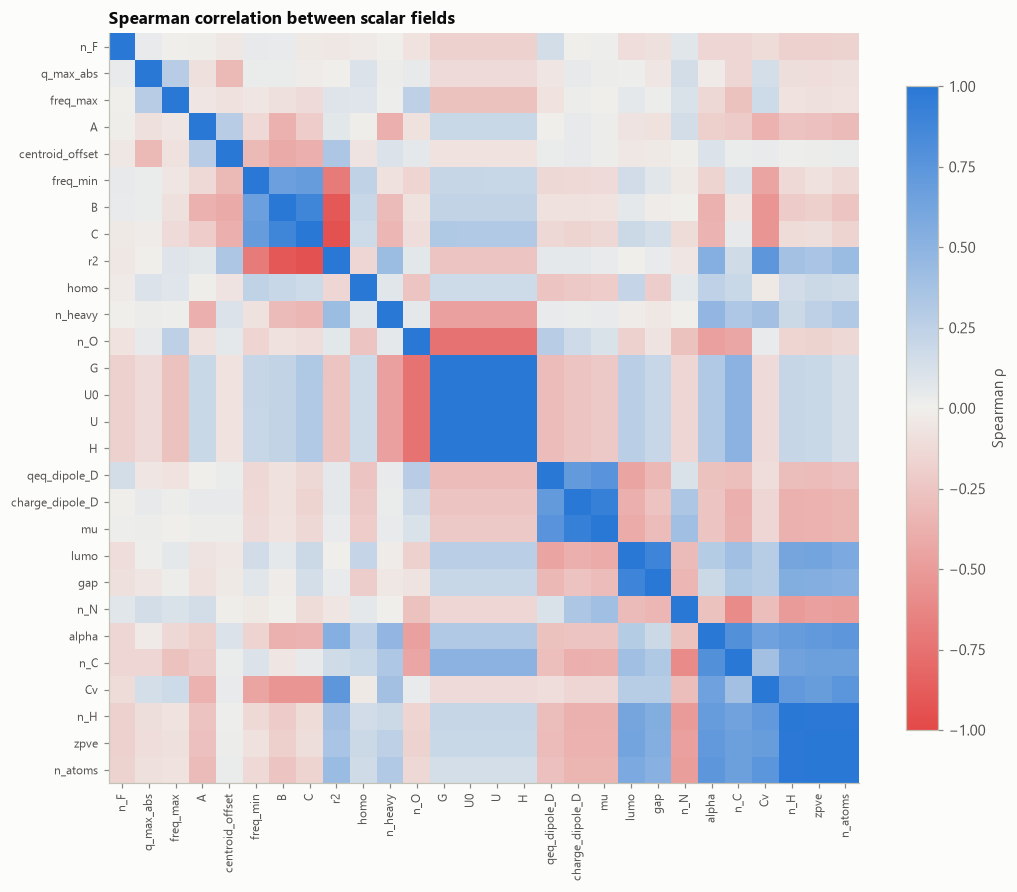

pairs with |ρ| ≥ 0.95 (8 at or above the cleaning threshold 0.99):


In [17]:
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

corr = candidates.join(y).corr(method="spearman")
dist = squareform(1 - corr.abs().to_numpy(), checks=False)
order = corr.index[leaves_list(linkage(dist, "average"))]
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr.to_numpy(), cmap=DIVERGING, vmin=-1, vmax=1)
ax.set(xticks=range(len(order)), yticks=range(len(order)), title="Spearman correlation between scalar fields")
ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticklabels(order, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.8)
fig.savefig(figure_file("explore01_correlations.png"))
plt.show()

threshold = CFG["cleaning"]["redundancy_spearman"]
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
near = upper[upper.abs() >= 0.95].sort_values(key=np.abs, ascending=False)
print(f"pairs with |ρ| ≥ 0.95 ({(near.abs() >= threshold).sum()} at or above the cleaning threshold {threshold}):")
display(near.rename("Spearman ρ").to_frame().style.format("{:+.4f}"))

## 11. Composition vs geometry: how much does the formula explain?

A model that sees only composition gives every isomer of a formula the same prediction. A one-way analysis of
variance by formula measures the cost: η² is the share of var(|μ|) explained by each formula's mean, and ω² its
bias-corrected version. Formulas with ≥ 5 molecules in P are used.

324 formulas with ≥ 5 molecules (98,861 molecules):
  variance explained by the formula: η² = 0.25, ω² = 0.25
  isomers of one formula: within-formula std 1.28 D (total 1.49 D); mean |μ − formula mean| 0.94 D, a floor for composition-only models


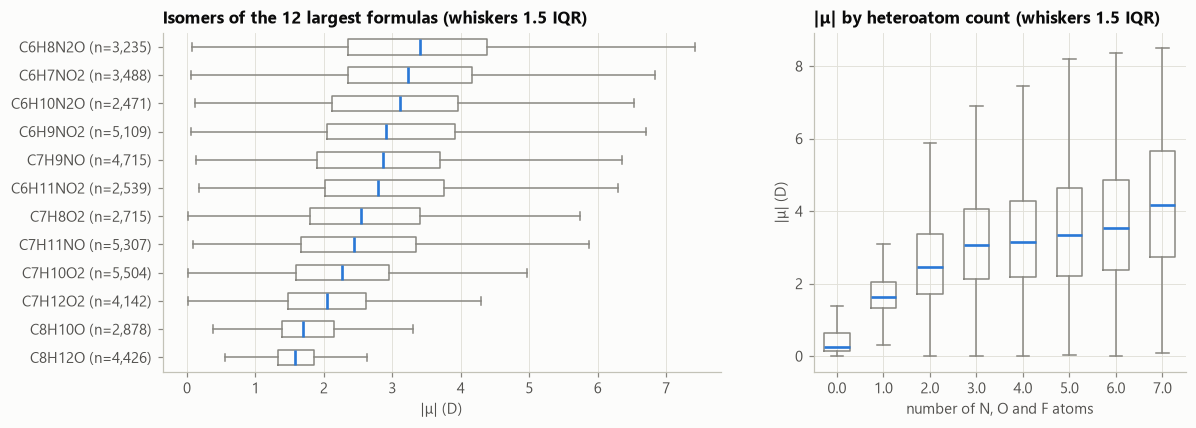

In [18]:
from qm9dipole.analysis import formula_variance

fv = formula_variance(y, formula, min_count=5)
print(f"{fv['n_formulas']} formulas with ≥ 5 molecules ({fv['n_molecules']:,} molecules):")
print(f"  variance explained by the formula: η² = {fv['eta2']:.2f}, ω² = {fv['omega2']:.2f}")
print(f"  isomers of one formula: within-formula std {fv['within_std']:.2f} D (total {fv['total_std']:.2f} D); "
      f"mean |μ − formula mean| {fv['within_mae']:.2f} D, a floor for composition-only models")

n_het = summaries["n_N"] + summaries["n_O"] + summaries["n_F"]
top12 = per_formula.index[:12]
order_f = y.groupby(formula).median().loc[top12].sort_values().index
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.5, 1]})
style = dict(color=MUTED, linewidth=1)
ax0.boxplot([y[formula == f] for f in order_f], orientation="horizontal", widths=0.55, showfliers=False,
            medianprops=dict(color=SERIES[0], linewidth=1.75), boxprops=style, whiskerprops=style, capprops=style)
ax0.set(yticks=range(1, len(order_f) + 1), yticklabels=[f"{f} (n={per_formula[f]:,})" for f in order_f],
        xlabel="|μ| (D)", title="Isomers of the 12 largest formulas (whiskers 1.5 IQR)")
ax0.grid(axis="y", visible=False)
groups_h = sorted(n_het.unique())
ax1.boxplot([y[n_het == h] for h in groups_h], positions=groups_h, widths=0.55, showfliers=False,
            medianprops=dict(color=SERIES[0], linewidth=1.75), boxprops=style, whiskerprops=style, capprops=style)
ax1.set(xlabel="number of N, O and F atoms", ylabel="|μ| (D)", title="|μ| by heteroatom count (whiskers 1.5 IQR)")
fig.savefig(figure_file("explore01_formula.png"))
plt.show()

## 12. The high-|μ| tail: can geometry recognize it?

X1 found that every model missed the molecules above 9 D almost completely, and that no feature identified them.
Most are **zwitterions**: a protonated amine (N with four bonds, +1) and a carboxylate (a carbon with two terminal
oxygens, −1) on one molecule, a full charge separated across it. Both groups are visible in the bond graph, so they
can be recognized from Z and R alone (`atoms.describe`, molecule-level `groups` block). This section checks how much
of the tail they account for, and what the rest is.

In [19]:
from qm9dipole.atoms import GROUP_NAMES

tail = y[y >= 6].index
grp = blocks_P.loc[tail, list(GROUP_NAMES)]
everyone = blocks_P[list(GROUP_NAMES)]
bands = pd.cut(y.loc[tail], [6, 9, 12, np.inf], right=False, labels=["6–9 D", "9–12 D", "≥ 12 D"])
flags = pd.DataFrame({
    "molecules": bands.value_counts().sort_index(),
    "zwitterion (ammonium + carboxylate)": grp["zwitterion"].groupby(bands, observed=True).mean(),
    "any ammonium N": (grp["n_ammonium"] > 0).groupby(bands, observed=True).mean(),
    "any carboxylate": (grp["n_carboxylate"] > 0).groupby(bands, observed=True).mean(),
    "any nitro-like N": (grp["n_nitro_like"] > 0).groupby(bands, observed=True).mean(),
})
display(flags.style.format({c: "{:.0%}" for c in flags.columns if c != "molecules"})
        .set_caption("Charged groups recognized from geometry, by |μ| band"))
print(f"all of P: zwitterion flag on {everyone['zwitterion'].mean():.2%}, ammonium N on {(everyone['n_ammonium'] > 0).mean():.2%}, "
      f"carboxylate on {(everyone['n_carboxylate'] > 0).mean():.2%}")
zw_all = everyone["zwitterion"].reindex(mol.index)
print(f"all of P: {int(zw_all.sum())} zwitterions; median |μ| {y[zw_all == 1].median():.1f} D vs {y[zw_all == 0].median():.1f} D; "
      f"share of the ≥ 9 D molecules they cover: {zw_all.loc[y[y >= 9].index].mean():.0%}")
others = y[(y >= 9) & (zw_all == 0)].sort_values(ascending=False)
display(mol.loc[others.index[:8], ["smiles", "mu"]].rename(columns={"mu": "|μ| (D)"}).style.format(precision=2)
        .set_caption("largest ≥ 9 D molecules that are NOT flagged as zwitterions"))

,molecules,zwitterion (ammonium + carboxylate),any ammonium N,any carboxylate,any nitro-like N
mu,,,,,
6–9 D,1601,0%,0%,1%,2%
9–12 D,79,32%,54%,42%,0%
≥ 12 D,144,71%,81%,81%,0%


all of P: zwitterion flag on 0.13%, ammonium N on 0.17%, carboxylate on 0.17%
all of P: 128 zwitterions; median |μ| 14.3 D vs 2.5 D; share of the ≥ 9 D molecules they cover: 57%


,smiles,|μ| (D)
id,,
130454,[NH3]CCC1=NOC(=O)[CH]1,20.98
130453,[NH3]CCc1noc([NH])n1,20.37
6683,[O]C(=O)CCNC=[NH2],18.69
97325,[NH2]=CNCC(=O)C(=O)[O],18.28
96679,CNC(=[NH2])OCC(=O)[O],16.74
54657,[O]C(=O)C1=CN[C](N)C1,16.62
6075,NC(=[NH2])OCC(=O)[O],16.17
129340,[NH2]=CNCc1nnnn1,15.86


## 13. Outliers

Two screens per field: |z| > 3 (assumes a roughly normal bulk) and Tukey's fences (beyond 1.5 IQR from the
quartiles). In a valid computed dataset an outlier is not an error. The project **keeps** the high-|μ| molecules
(DECISIONS.md). They weigh heavily on RMSE, which is why MAE is the primary metric.

In [20]:
z = (scalars - scalars.mean()) / scalars.std()
q1, q3 = scalars.quantile(0.25), scalars.quantile(0.75)
iqr = q3 - q1
tukey = (scalars < q1 - 1.5 * iqr) | (scalars > q3 + 1.5 * iqr)
outliers = pd.DataFrame({"|z| > 3": (z.abs() > 3).sum(), "outside Tukey fences": tukey.sum(),
                         "share outside fences": tukey.mean()})
display(outliers.sort_values("|z| > 3", ascending=False).style.format({"share outside fences": "{:.1%}"}))

,|z| > 3,outside Tukey fences,share outside fences
n_heavy,2844,15579,15.7%
n_N,2200,96,0.1%
r2,1563,4962,5.0%
n_F,1462,1462,1.5%
homo,1232,4653,4.7%
freq_min,1221,3834,3.9%
U,1087,1744,1.8%
H,1087,1744,1.8%
U0,1087,1744,1.8%
G,1087,1744,1.8%


## 14. Findings and recommendations

The table below is what the later notebooks act on. Each row names a finding and the step that handles it. It is
saved to `results/development/explore01_recommendations.csv`, and notebook 02 prints it before acting on it.

In [21]:
skewed = [c for c in stats.index if abs(stats.loc[c, "skew"]) > CFG["standardization"]["skew_threshold"]]
r2_lin = charge_fit.loc["all per-atom features, linear", "R² (out of fold)"]
r2_gbt = charge_fit.loc["all per-atom features, boosted trees", "R² (out of fold)"]
r2_el = charge_fit.loc["element only (5 indicators)", "R² (out of fold)"]
recommendations = pd.DataFrame([
    ("roles", "q, the 11 electronic/thermal properties, freqs", "DFT outputs from the same calculation as |μ|",
     "exploration-only block; never in a headline feature set, Track A included", "02"),
    ("A, B, C", "rotational constants", "exactly 505.379 GHz·amu·Å² / I(Z, R), so legal; A = 0 marks a linear molecule",
     "replace with inertia moments computed from Z and R (finite, same information)", "02"),
    ("freqs", f"{int(doubled.sum())} doubled lists", "raw-file artifact: the list is printed twice",
     "keep the first copy; summarize the spectrum (exploration only)", "02"),
    ("duplicates", f"{len(geo)} geometric duplicates left in P", "removed before splitting (notebook 01); InChI merges tautomers",
     "nothing to do; identify molecules by geometry, never InChI", "—"),
    ("redundancy", f"{(near.abs() >= threshold).sum()} pairs with |ρ| ≥ {threshold}", "e.g. U0/U/H/G, size counts",
     f"drop the later of each pair (cleaning.redundancy_spearman = {threshold})", "02"),
    ("bond lengths", "C≡C, C≡N, C=O, N=O peaks separated by empty valleys at full scale",
     "bond order is readable from geometry", "count multiple bonds by length, per molecule and per atom", "02"),
    ("per-atom charges", f"out-of-fold R² for the Mulliken charge: element {r2_el:.2f}, linear {r2_lin:.2f}, trees {r2_gbt:.2f}",
     "an atom's charge is mostly set by its local environment, which Z and R describe",
     "per-atom environment features (atoms.py) and a latent-charge model that predicts charges and outputs |Σ qᵢ cᵢ|", "02, 04"),
    ("QEq", f"QEq dipole: Spearman ρ = {assoc.loc['qeq_dipole_D', 'Spearman ρ']:.2f}, MI {assoc.loc['qeq_dipole_D', 'MI (nats)']:.2f} nats",
     "a no-fit physics estimate from Z and R alone already tracks |μ|", "molecule-level qeq block and per-atom QEq charge", "02"),
    ("zwitterions", f"{int(zw_all.sum())} in P; cover {zw_all.loc[y[y >= 9].index].mean():.0%} of the ≥ 9 D molecules",
     "a protonated amine plus a carboxylate is visible in the bond graph", "charged-group features (groups block, per-atom flags)", "02"),
    ("formula imbalance", f"top 10 formulas hold {share.iloc[9]:.0%} of P; nine heavy atoms {heavy.get(9, 0) / len(P):.0%}",
     "models learn mostly from a few common formulas", "measure new-formula error on the development holdout (dev_unseen)", "05"),
    ("long tails", f"{len(skewed)} fields with |skew| > {CFG['standardization']['skew_threshold']}",
     ", ".join(skewed[:8]) + ("…" if len(skewed) > 8 else ""), "compare scalings by CV / development error", "03"),
    ("target", f"skewness {y.skew():.2f}; √|μ| {np.sqrt(y).skew():.2f}", "right tail of zwitterions; spike near 0",
     "compare raw, √ and log(1+·) targets (predictions inverted to debye)", "03"),
    ("composition", f"ω² = {fv['omega2']:.2f}", "the formula explains a minority of the variance",
     "geometry-aware features are essential; composition-only is a baseline", "04"),
    ("outliers", f"{(y >= 9).sum()} molecules ≥ 9 D", "valid computed values",
     "keep; report MAE (primary), RMSE, and RMSE without the tail", "05"),
], columns=["topic", "evidence", "finding", "action", "notebook"])
_ = save_result(recommendations, "explore01_recommendations", label="exploratory EDA on the training pool P (X2)")
display(recommendations.style.hide(axis="index"))

topic,evidence,finding,action,notebook
roles,"q, the 11 electronic/thermal properties, freqs",DFT outputs from the same calculation as |μ|,"exploration-only block; never in a headline feature set, Track A included",02
"A, B, C",rotational constants,"exactly 505.379 GHz·amu·Å² / I(Z, R), so legal; A = 0 marks a linear molecule","replace with inertia moments computed from Z and R (finite, same information)",02
freqs,255 doubled lists,raw-file artifact: the list is printed twice,keep the first copy; summarize the spectrum (exploration only),02
duplicates,0 geometric duplicates left in P,removed before splitting (notebook 01); InChI merges tautomers,"nothing to do; identify molecules by geometry, never InChI",—
redundancy,8 pairs with |ρ| ≥ 0.99,"e.g. U0/U/H/G, size counts",drop the later of each pair (cleaning.redundancy_spearman = 0.99),02
bond lengths,"C≡C, C≡N, C=O, N=O peaks separated by empty valleys at full scale",bond order is readable from geometry,"count multiple bonds by length, per molecule and per atom",02
per-atom charges,"out-of-fold R² for the Mulliken charge: element 0.46, linear 0.97, trees 0.99","an atom's charge is mostly set by its local environment, which Z and R describe",per-atom environment features (atoms.py) and a latent-charge model that predicts charges and outputs |Σ qᵢ cᵢ|,"02, 04"
QEq,"QEq dipole: Spearman ρ = 0.76, MI 0.52 nats",a no-fit physics estimate from Z and R alone already tracks |μ|,molecule-level qeq block and per-atom QEq charge,02
zwitterions,128 in P; cover 57% of the ≥ 9 D molecules,a protonated amine plus a carboxylate is visible in the bond graph,"charged-group features (groups block, per-atom flags)",02
formula imbalance,top 10 formulas hold 42% of P; nine heavy atoms 84%,models learn mostly from a few common formulas,measure new-formula error on the development holdout (dev_unseen),05


### Summary

1. **The data is clean at full scale.** All 99,198 pool molecules pass every consistency rule. The only artifacts are
   255 frequency lists printed twice (identical halves) and 5 linear molecules stored with A = 0. No geometric
   duplicate is left (notebook 01 removed them). 1,824 groups of pool molecules share an InChI but are different
   tautomers, |μ| up to 8.5 D apart: InChI is not an identity test.
2. **Target.** Mean 2.71 D, median 2.52 D, std 1.49 D; skewness 1.49 (√|μ|: −0.05); 41 exact zeros; 223 molecules
   (0.22%) at ≥ 9 D, up to 29.6 D. Always predicting the median scores MAE 1.146 D: the floor to beat.
3. **Formula imbalance.** 497 formulas, median 12 molecules each; the 10 largest hold 42% of P (C7H10O2 alone has
   5,504) and 84% of molecules have nine heavy atoms. The formula explains even less than in X1's capped pool
   (ω² = 0.25 vs 0.31); isomers differ by 1.28 D (std), and a composition-only model cannot beat MAE 0.94 D.
4. **An atom's charge is set by its local environment, which Z and R describe.** Out of fold, per-atom features from
   Z and R predict the Mulliken charge with R² = 0.966 (linear) and 0.994 (boosted trees), against 0.46 for the
   element alone and 0.78 for the no-fit QEq charge. Adding up the *predicted* charges as point charges tracks |μ|
   nearly as well as the DFT charges do (r = 0.902 vs 0.937). This is the case for X2's latent-charge model: predict
   a charge per atom from geometry, then let the vector sum do the rest.
5. **The QEq dipole is the best legal single field:** r = 0.72, ρ = 0.76, MI 0.52 nats, against 0.16 for the best
   count (n_C). It needs no fitting at all: tabulated electronegativities and hardnesses balanced against Coulomb
   interactions on the actual geometry.
6. **The zwitterion tail is visible in geometry.** 128 pool molecules carry an ammonium N and a carboxylate; their
   median |μ| is 14.3 D, and they make up 57% of the molecules at ≥ 9 D. A carboxylate is present in 81% of the
   molecules at ≥ 12 D. Most of the rest pair a carboxylate with an amidinium or iminium cation (C=[NH2]⁺), which the
   4-bond ammonium rule misses but which a per-atom model can learn from the environment.
7. **Bond orders from lengths, re-checked on 14× more bonds.** The C≡C, C≡N, C=O and N=O cutoffs still sit in empty
   or near-empty valleys (0, 0, 69 and 6 bonds within ±0.02 Å). **The C–N multiple/single cutoff at 1.43 Å does
   not:** 12,518 of 169,061 C–N bonds lie within ±0.02 Å, a dip rather than a valley, because aromatic, amide and
   single C–N bonds overlap at full scale. The count stays (a fixed function of geometry, so legal and invariant) but
   is fuzzy; the per-atom radial features carry the lengths themselves.
8. **Raw frames carry no chemistry** (1.6% of stored frames are principal-axis aligned), which supports invariant
   inputs. **Redundancy:** U0, U, H and G are identical in rank; zpve tracks n_H and n_atoms (ρ ≥ 0.99).

**Carried forward:** notebook 02 implements every row of the recommendations table: per-atom environments and the
QEq and charged-group blocks are the new features; notebook 03 re-tests the transforms the shapes in point 2 call
for.